**Mapping of Inundation Dynamics of Nabajjuzi**

Script for mapping inundated forests and open water in Nabajjuzi wetland located in Central Uganda. This is based on the paper: https://doi.org/10.3390/rs15061705

**Analysis conducted**
1.   Received Nabajjuzi wetlands shapefile
2.   Downloaded HydroBASINS Continental downloads for Africa & extracted level 8 basins that overlap with the nabajjuzi shapefile
3.   Prepared radar & optical mosaics in Sepal for the hydrosheds area using Nabajjuzi hydrosheds shapefile as the boundary
4.   Performed SAR RGB, False color, Water / inundation visualisation on large Nabajjuzi hydrosheds area
5.   Cropped out area of Nabajjuzi wetlands for subsequent analysis
5.   Normalised Difference Polarisation Index (NDPI)
6.   List item



In [18]:
# Import required libraries

import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from google.colab import drive
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap
from rasterio.plot import show
from rasterio.merge import merge
from rasterio.mask import mask
from rasterio.plot import show
from rasterio.enums import Resampling
from shapely.geometry import box, mapping

In [19]:
# Mount the drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
# Specify link to directory where raster files are saved

nabajjuzi = '/content/drive/MyDrive/GitHub_Desktop/Data/nabajjuzi'

In [21]:
# List the files in the directory

file_path = os.listdir(nabajjuzi)
file_path

['Nabajjuzi_Radar_Mosaic_2025.tif', 'nabajjuzi_wetland_shapefile']

In [22]:
# Visualise one raster layer

# Extract key SAR bands (VV & VH mean)

file_path1 = "/content/drive/MyDrive/GitHub_Desktop/Data/nabajjuzi/Nabajjuzi_Radar_Mosaic_2025.tif"
nabajjuzi_radar = rasterio.open(file_path1)

# Now check bands
print(f"Number of bands: {nabajjuzi_radar.count}")
print(f"Band descriptions: {nabajjuzi_radar.descriptions}")

Number of bands: 10
Band descriptions: ('VV_min', 'VV_mean', 'VV_med', 'VV_max', 'VV_std', 'VH_min', 'VH_mean', 'VH_med', 'VH_max', 'VH_std')


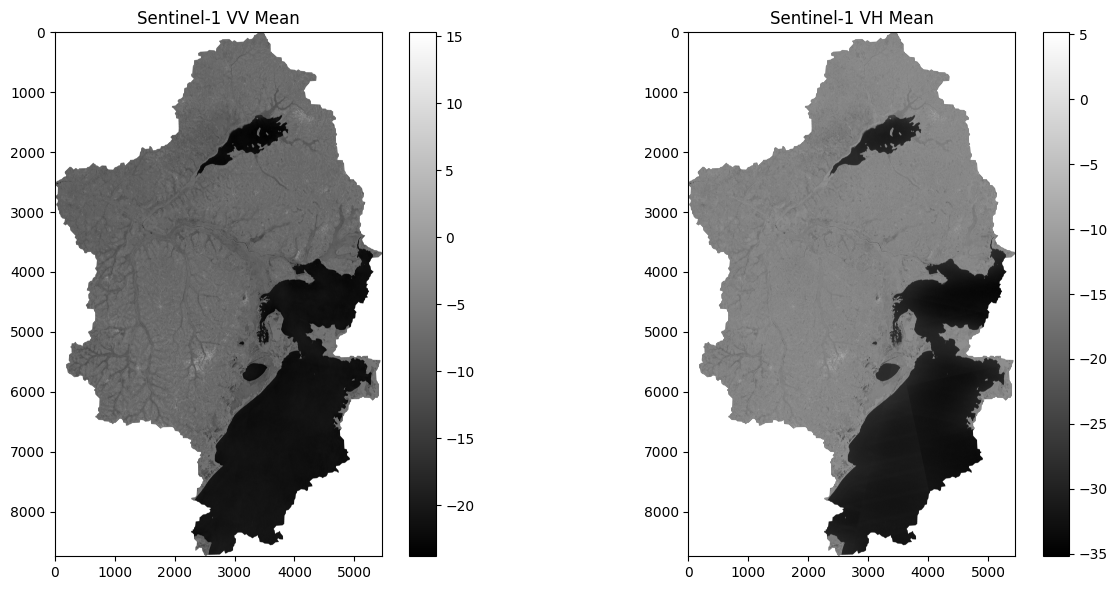

In [23]:
# Plot VV and VH separately

vv_mean = nabajjuzi_radar.read(2)
vh_mean = nabajjuzi_radar.read(7)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im1 = axes[0].imshow(vv_mean, cmap="gray")
axes[0].set_title("Sentinel-1 VV Mean")
plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

im2 = axes[1].imshow(vh_mean, cmap="gray")
axes[1].set_title("Sentinel-1 VH Mean")
plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [24]:
# Crop to area of Nabajjuzi wetland shapefile

# Find the shapefile path

folder_path = "/content/drive/MyDrive/GitHub_Desktop/Data/nabajjuzi/nabajjuzi_wetland_shapefile"

nabajjuzi_shapefile = []

for root, dirs, files in os.walk(folder_path):
    for file in files:
        if file.endswith(".shp"):
            nabajjuzi_shapefile.append(os.path.join(root, file))

nabajjuzi_shapefile

['/content/drive/MyDrive/GitHub_Desktop/Data/nabajjuzi/nabajjuzi_wetland_shapefile/nabajjuzi_wetland.shp']

In [25]:
# Read the shapefile

shp_path = nabajjuzi_shapefile[0]   # take first shapefile found
nabajjuzi_wetland = gpd.read_file(shp_path)

print(nabajjuzi_wetland.head())

    USE   LUC_         W_ha  CLASS STOCK  BPERC          AREA STYPE  PSUBJ  \
0  None  34454     0.259943      1    ME      0  2.599427e+03     s   4100   
1  None  34464     0.259943      1    ME      0  2.599426e+03     s   4100   
2  None  32315   823.032524      7    NO      0  8.230325e+06     p   4100   
3  None  33356  1633.910960      7    NO      0  1.633911e+07     p   4100   
4  None  34054  4125.110476      7    NO      0  4.125110e+07     p   4100   

       STRATA BTYPE  LUC_ID     PERIMETER  \
0        1sME     0   19076     203.93764   
1        1sME     0   19077     203.93764   
2  7pNO/B0-0%     0   42233   40673.51379   
3  7pNO/B0-0%     0   42993   74107.64737   
4  7pNO/B0-0%     0   43220  208997.00652   

                                            geometry  
0  POLYGON ((31.65422 -0.18868, 31.65422 -0.18822...  
1  POLYGON ((31.65312 -0.18946, 31.65312 -0.18899...  
2  POLYGON ((31.66356 0.02745, 31.66358 0.02764, ...  
3  POLYGON ((31.68669 -0.1395, 31.68697 

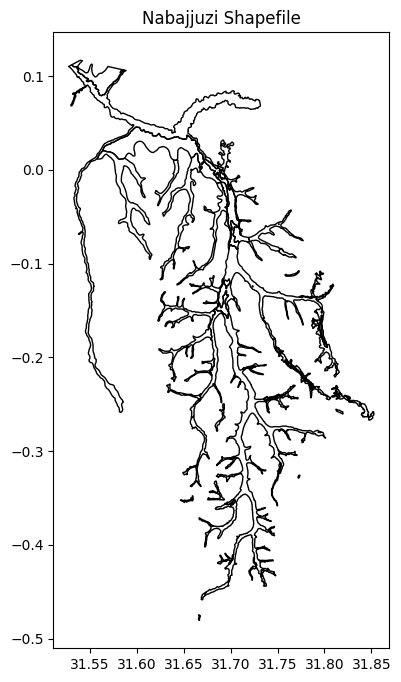

In [26]:
# Visualize the shapefile

nabajjuzi_wetland.plot(figsize=(8, 8), edgecolor="black", facecolor="none")
plt.title("Nabajjuzi Shapefile")
plt.show()

In [27]:
# Overlay the Nabajjuzi wetland shapefile onto the Nabajjuzi hydrosheds raster

# Ensure matching coordinate reference systems
print("Raster CRS:", nabajjuzi_radar.crs)
print("Shapefile CRS:", nabajjuzi_wetland.crs)

# Reproject shapefile if needed
if nabajjuzi_wetland.crs != nabajjuzi_radar.crs:
    nabajjuzi_wetland = nabajjuzi_wetland.to_crs(src.crs)

Raster CRS: EPSG:4326
Shapefile CRS: EPSG:4326


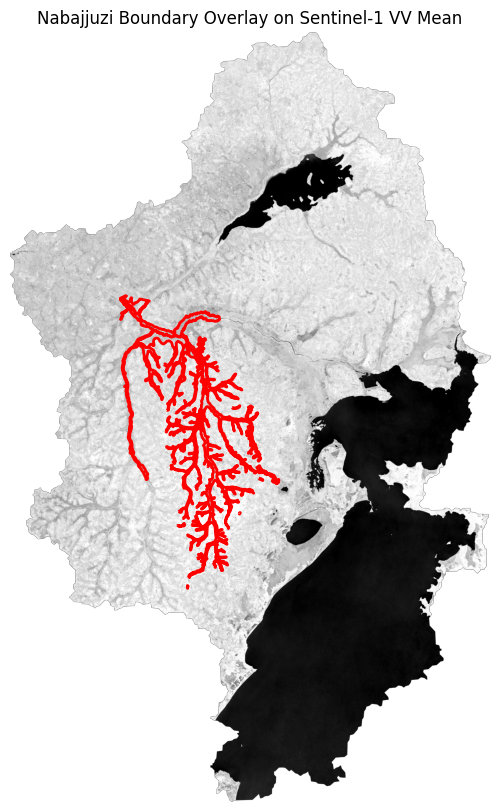

In [28]:
# Normalize function (Stretching between the absolute min and max of the image)
def normalize(img):
    p2, p98 = np.nanpercentile(img, [2, 98]) # Clips to the 2nd and 98th percentile
    return np.clip((img - p2) / (p98 - p2), 0, 1)

from rasterio.plot import show
from rasterio.transform import array_bounds

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# This plots with real-world coordinates, not pixel indices
show(normalize(vv_mean), ax=ax, cmap="gray", transform=nabajjuzi_radar.transform)

# Reproject shapefile to match raster CRS if needed
wetland_reproj = nabajjuzi_wetland.to_crs(nabajjuzi_radar.crs)
wetland_reproj.boundary.plot(ax=ax, edgecolor="red", linewidth=2)

ax.set_title("Nabajjuzi Boundary Overlay on Sentinel-1 VV Mean")
ax.axis("off")

plt.show()


✅ Clipped raster saved → Bands: 10, Height: 3326, Width: 1813


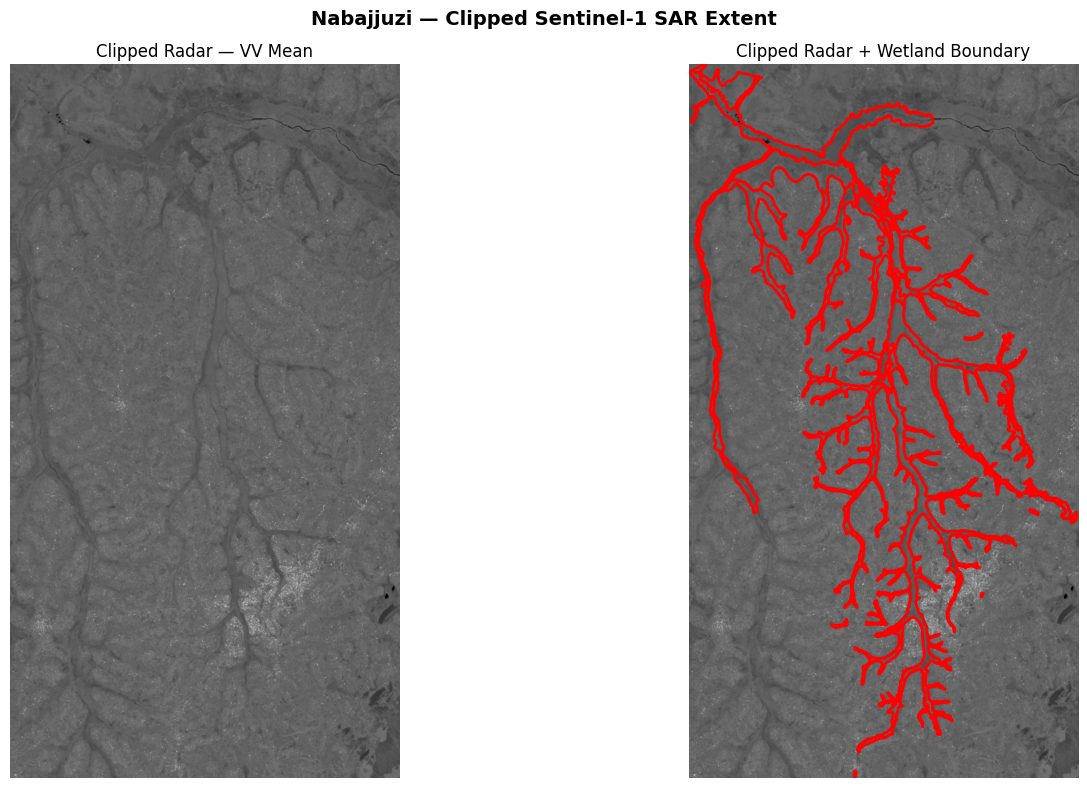

In [29]:
# Clip the radar raster to the rectangular extent of the Nabajjuzi wetland

# 1. Reproject shapefile to match raster CRS
wetland_reproj = nabajjuzi_wetland.to_crs(nabajjuzi_radar.crs)

# 2. Get the bounding box (rectangular extent) of the shapefile
bounds = wetland_reproj.total_bounds  # (minx, miny, maxx, maxy)
bbox = box(*bounds)                   # shapely rectangle

# 3. Clip raster to the bounding box
clipped_data, clipped_transform = mask(
    nabajjuzi_radar,
    [mapping(bbox)],
    crop=True
)

# 4. Update metadata
clipped_meta = nabajjuzi_radar.meta.copy()
clipped_meta.update({
    "height": clipped_data.shape[1],
    "width": clipped_data.shape[2],
    "transform": clipped_transform
})

# 5. Save the clipped raster
output_path = "nabajjuzi_radar_clipped.tif"
with rasterio.open(output_path, "w", **clipped_meta) as dest:
    dest.write(clipped_data)

print(f"✅ Clipped raster saved → Bands: {clipped_data.shape[0]}, Height: {clipped_data.shape[1]}, Width: {clipped_data.shape[2]}")

# 6. Reload and visualise
nabajjuzi_clipped = rasterio.open(output_path)

def normalize(img):
    return (img - np.nanmin(img)) / (np.nanmax(img) - np.nanmin(img) + 1e-6)

vv_mean_clipped = nabajjuzi_clipped.read(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left — clipped raster alone
show(normalize(vv_mean_clipped), ax=axes[0], cmap="gray", transform=nabajjuzi_clipped.transform)
axes[0].set_title("Clipped Radar — VV Mean")
axes[0].axis("off")

# Right — clipped raster with boundary overlay
show(normalize(vv_mean_clipped), ax=axes[1], cmap="gray", transform=nabajjuzi_clipped.transform)
wetland_reproj.boundary.plot(ax=axes[1], edgecolor="red", linewidth=2)
axes[1].set_title("Clipped Radar + Wetland Boundary")
axes[1].axis("off")

plt.suptitle("Nabajjuzi — Clipped Sentinel-1 SAR Extent", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [30]:
# Analysis on the clipped area

# Understand bands contained in clipped raster

print(f"Number of bands: {nabajjuzi_clipped.count}")
print(f"Band descriptions: {nabajjuzi_clipped.descriptions}")

Number of bands: 10
Band descriptions: (None, None, None, None, None, None, None, None, None, None)


In [31]:
# Define band names manually based on known band order
band_names = ('VV_min', 'VV_mean', 'VV_med', 'VV_max', 'VV_std',
              'VH_min', 'VH_mean', 'VH_med', 'VH_max', 'VH_std')

# Map band index (1-based) to name
band_map = {i+1: name for i, name in enumerate(band_names)}

print(f"Number of bands: {nabajjuzi_clipped.count}")
print(f"Band descriptions: {band_names}")
print(f"\nBand map:")
for idx, name in band_map.items():
    print(f"  Band {idx}: {name}")

Number of bands: 10
Band descriptions: ('VV_min', 'VV_mean', 'VV_med', 'VV_max', 'VV_std', 'VH_min', 'VH_mean', 'VH_med', 'VH_max', 'VH_std')

Band map:
  Band 1: VV_min
  Band 2: VV_mean
  Band 3: VV_med
  Band 4: VV_max
  Band 5: VV_std
  Band 6: VH_min
  Band 7: VH_mean
  Band 8: VH_med
  Band 9: VH_max
  Band 10: VH_std


In [32]:
# Perform first set of visualizations

# Read all bands from clipped raster
vv_mean_c   = nabajjuzi_clipped.read(1)
vh_mean_c   = nabajjuzi_clipped.read(2)
vv_min_c    = nabajjuzi_clipped.read(3)

def normalize(img):
    p2, p98 = np.nanpercentile(img, [2, 98])
    return np.clip((img - p2) / (p98 - p2), 0, 1)

# --- RGB Composite ---
rgb = np.dstack((
    normalize(vv_mean_c),
    normalize(vh_mean_c),
    normalize(vv_min_c)
))

# --- False Color (VV | VH | VV/VH ratio) ---
ratio = np.where(vh_mean_c != 0, vv_mean_c / vh_mean_c, 0)
false_color = np.dstack((
    normalize(vv_mean_c),
    normalize(vh_mean_c),
    normalize(ratio)
))

# --- SAR NDVI equivalent: (VV - VH) / (VV + VH) ---
# Known as the Radar Vegetation Index (RVI proxy)
numerator   = vv_mean_c - vh_mean_c
denominator = vv_mean_c + vh_mean_c
sar_ndvi    = np.where(denominator != 0, numerator / denominator, 0)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

# RGB
axes[0].imshow(rgb)
axes[0].set_title("SAR RGB Composite\nVV_mean | VH_mean | VV_min", fontsize=11)
axes[0].axis("off")

# False Color
axes[1].imshow(false_color)
axes[1].set_title("False Color Composite\nVV | VH | VV/VH Ratio", fontsize=11)
axes[1].axis("off")

# SAR NDVI
ndvi_plot = axes[2].imshow(sar_ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
axes[2].set_title("SAR Vegetation Index\n(VV - VH) / (VV + VH)", fontsize=11)
axes[2].axis("off")
plt.colorbar(ndvi_plot, ax=axes[2], fraction=0.046, pad=0.04, label="RVI Index")

plt.suptitle("Nabajjuzi Wetland — Sentinel-1 SAR Analysis (Clipped)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

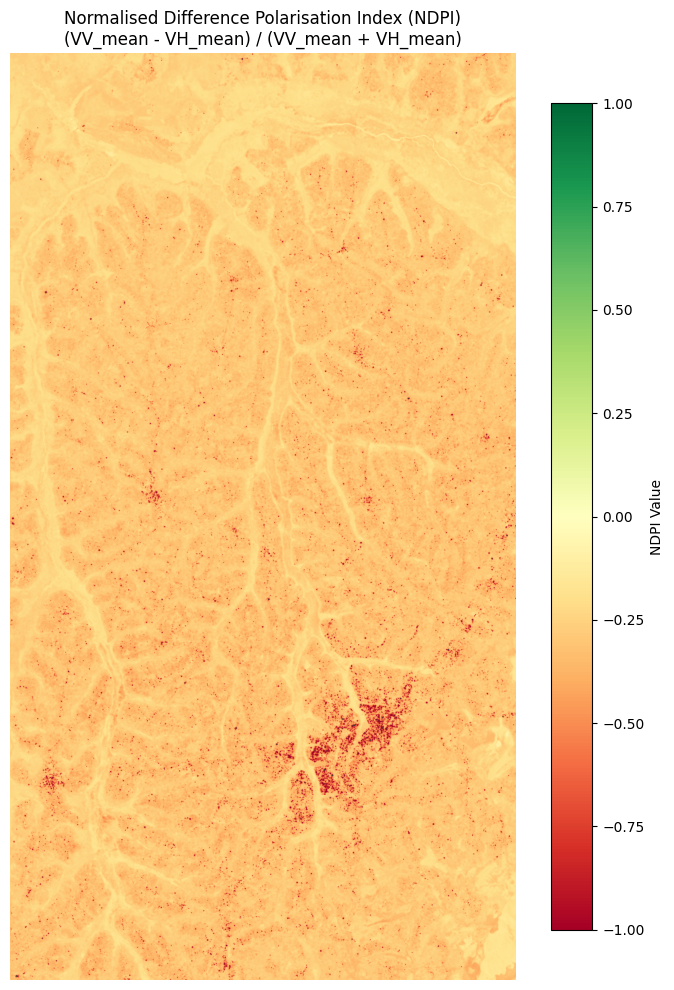

NDPI Stats:
  Min  : -1562.0869
  Max  : 1470.2954
  Mean : -0.2985
  Std  : 1.5798


In [37]:
# Read VV and VH mean bands from clipped raster
vv_mean_c = nabajjuzi_clipped.read(2).astype(np.float32)
vh_mean_c = nabajjuzi_clipped.read(7).astype(np.float32)

# Calculate NDPI
ndpi = (vv_mean_c - vh_mean_c) / (vv_mean_c + vh_mean_c)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

ndpi_plot = ax.imshow(ndpi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(ndpi_plot, ax=ax, fraction=0.046, pad=0.04, label="NDPI Value")

ax.set_title("Normalised Difference Polarisation Index (NDPI)\n(VV_mean - VH_mean) / (VV_mean + VH_mean)", fontsize=12)
ax.axis("off")

plt.tight_layout()
plt.show()

# Summary statistics
print(f"NDPI Stats:")
print(f"  Min  : {np.nanmin(ndpi):.4f}")
print(f"  Max  : {np.nanmax(ndpi):.4f}")
print(f"  Mean : {np.nanmean(ndpi):.4f}")
print(f"  Std  : {np.nanstd(ndpi):.4f}")


In [39]:
# Categorical Classification based on NDPI thresholds

# Classify NDPI into 3 categories
# Open Water:           NDPI < -0.3  (very low — strong VH return)
# Inundated Vegetation: -0.3 <= NDPI < 0.0  (moderate — mixed signal)
# Background Landcover:  NDPI >= 0.0  (positive — VV dominant)

classified = np.full(ndpi.shape, np.nan)
classified = np.where(ndpi < -0.3,               1, classified)  # Open Water
classified = np.where((ndpi >= -0.3) & (ndpi < 0), 2, classified)  # Inundated Vegetation
classified = np.where(ndpi >= 0.0,               3, classified)  # Background Landcover

# Colormap matching your image
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

cmap = ListedColormap(['#1a6faf', '#00cfcf', '#2d6a2d'])  # Blue, Cyan, Dark Green
bounds = [0.5, 1.5, 2.5, 3.5]
norm = BoundaryNorm(bounds, cmap.N)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

img = ax.imshow(classified, cmap=cmap, norm=norm)

# Legend
legend_patches = [
    mpatches.Patch(color='#00cfcf', label='Inundated Vegetation'),
    mpatches.Patch(color='#1a6faf', label='Open Water'),
    mpatches.Patch(color='#2d6a2d', label='Background Landcover'),
]
ax.legend(handles=legend_patches, loc='lower left', fontsize=10, framealpha=0.8)

ax.set_title("NDPI Categorical Classification\nNabajjuzi Wetland — Sentinel-1 SAR", fontsize=12)
ax.axis("off")

plt.tight_layout()
plt.show()

# Class statistics
total_pixels = np.sum(~np.isnan(classified))
print(f"Classification Stats:")
print(f"  Open Water           : {np.sum(classified == 1):,} px ({100 * np.sum(classified == 1) / total_pixels:.1f}%)")
print(f"  Inundated Vegetation : {np.sum(classified == 2):,} px ({100 * np.sum(classified == 2) / total_pixels:.1f}%)")
print(f"  Background Landcover : {np.sum(classified == 3):,} px ({100 * np.sum(classified == 3) / total_pixels:.1f}%)")

NameError: name 'vv' is not defined